# DASP Basics

**Herzlich willkommen zur ersten DASP-Übung!** 🥳

Anbei werden ein paar grundlegende Tipps und Tricks vorgestellt...

## Audio Ein- und Ausgabe

Grundsätzlich verarbeiten wir die Audiosamples (auch Abtastwerte oder Signalamplituden) als `float` Zahlen. Der Wertebereich beträgt jeweils zwischen `-1.0` und `+1.0`.

Abgespielt können die Audiosamples auf verschiedene Art und Weise:

- Direkt im Python Notebook via [IPython.display.Audio](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.Audio),
- Indirekt über eine Audiodatei, welche anschließend in einem externen Audioplayer zu öffnen ist.

Am einfachsten ist es die Audiodateien im sog. [WAV](https://en.wikipedia.org/wiki/WAV) Dateiformat unkomprimiert zu speichern. Das kann Python mittlerweile [out of box](https://docs.python.org/3/library/wave.html).

Gewöhnlich muss die Signalamplitude jedoch als `integer` Zahl abgebildet werden, um in der Audiodatei binär gespeichert zu werden.

Betrachte hierfür den darauf folgenden Codebeispiel.

## Audioausgabe in Python

In [2]:
import IPython as ipy
import matplotlib.pyplot as plot
import numpy as np
import wave

In [9]:
SR = 44100  # sample rate in hertz
T  = 1      # total duration in seconds

amplitude = 0.5  # signal amplitude scaler
frequency = 440  # signal frequency in hertz

time = np.arange(0, T, 1 / SR)  # discrete signal time points

signal = amplitude * np.sin(2 * np.pi * frequency * time)

In [10]:
ipy.display.Audio(signal, rate=SR, normalize=False)

In [11]:
with wave.open('signal.wav', 'w') as file:

    file.setframerate(SR)  # hertz
    file.setsampwidth(2)   # int16
    file.setnchannels(1)   # mono

    # clip to [-1, +1]
    data = signal.clip(-1, +1)

    # convert from float [-1, +1] to int16 [-32768, +32767]
    data = ((data * 32767.5) - 0.5).astype(np.int16)

    file.writeframes(data)

In [12]:
ipy.display.Audio('signal.wav')

(-1.0, 1.0)

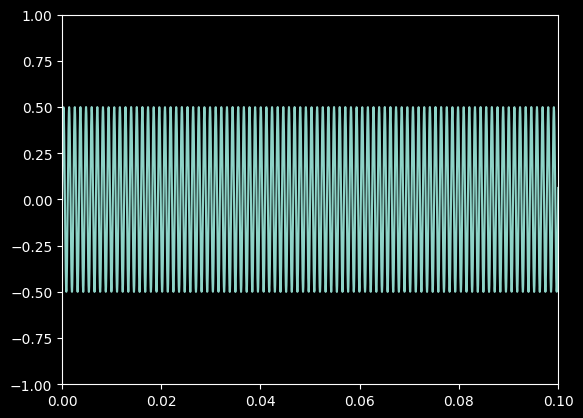

In [13]:
plot.plot(time, signal)
plot.xlim((0, 100e-3))
plot.ylim((-1, +1))

## Python Bibliothek "dhbw"

Die native Python Audioschnittstelle ist syntaktisch etwas umständlich. Stattdessen kann die vorlesungsbegleitende Python Bibliothek [dhbw](https://pypi.org/project/dhbw) verwendet werden.

In [14]:
from dhbw import dasp

In [17]:
dasp.io.write('signal', signal, sr=SR)
signal, time, SR = dasp.io.read('signal')

In [18]:
dasp.io.display(signal, sr=SR)

<module 'dhbw.dasp.plot' from 'C:\\Users\\Service\\idea-projects\\Labor1-Audio-Signal-Verarbeitung\\.venv\\Lib\\site-packages\\dhbw\\dasp\\plot.py'>

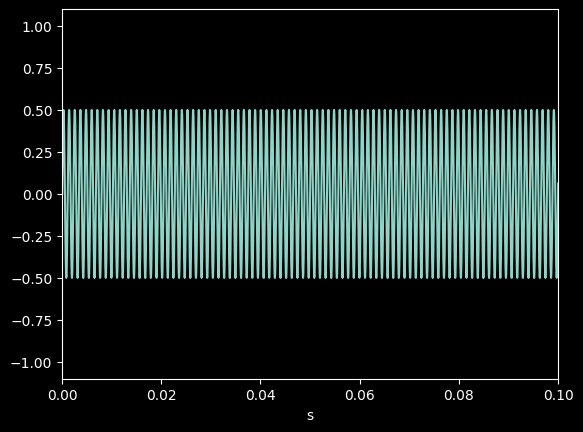

In [19]:
dasp.plot.signal(time, signal, xlim=100e-3)